<a href="https://colab.research.google.com/github/dariakadina/satprak/blob/main/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem 1
Implement serial test and apply to a `samples`

In [1]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

samples = [rng() for _ in range(1000)]

def serial_test(samples, bins=10):
    n = len(samples) // 2 * 2

    pairs = np.array([samples[:n:2], samples[1:n:2]]).T

    observed, _, _ = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=bins)
    observed = observed.flatten()


    expected = np.full(bins * bins, n // 2 / (bins * bins))


    chi2_stat, p_value = stats.chisquare(observed, expected)

    return chi2_stat, p_value

chi2, p = serial_test(samples)
print(f"chi-square statistic = {chi2:.4f}")
print(f"p-value = {p:.4f}")


alpha = 0.05
if p > alpha:
    print("Результат: Нет оснований отвергнуть гипотезу о случайности (p > 0.05)")
else:
    print("Результат: Отвергаем гипотезу о случайности (p < 0.05)")

chi-square statistic = 100.4000
p-value = 0.4418
Результат: Нет оснований отвергнуть гипотезу о случайности (p > 0.05)


### Permutation test

We again decompose the sequence $x_1, x_2, x_3, ..., x_{dn}$ into consecutive series of length $d$: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), \ldots, (x_{nd-d+1}, x_{nd})$. A series of $d$ elements can be ordered in $d!$ ways and each way of ordering is equally probable. Hence the idea of the test is to count how many times each ordering occurs among $n$ series and apply the $\chi^2$ test.

### Problem 2*
Implement permutation test and apply to a `samples`

In [4]:
import numpy as np
from scipy import stats
from itertools import permutations

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

samples = [rng() for _ in range(1000)]

def permutation_test(samples, d=3):

    n = len(samples)
    n_series = n // d
    samples_trimmed = samples[:n_series * d]

    series = np.array(samples_trimmed).reshape(n_series, d)


    permutations_observed = []
    for s in series:
        perm_idx = tuple(np.argsort(s))
        permutations_observed.append(perm_idx)

    all_perms = list(permutations(range(d)))
    n_perms = len(all_perms)

    perm_to_idx = {perm: i for i, perm in enumerate(all_perms)}

    observed = np.zeros(n_perms)
    for p in permutations_observed:
        observed[perm_to_idx[p]] += 1

    expected = np.full(n_perms, n_series / n_perms)

    chi2_stat, p_value = stats.chisquare(observed, expected)

    return chi2_stat, p_value


chi2, p = permutation_test(samples, d=3)
print(f"chi-square statistic = {chi2:.4f}")
print(f"p-value = {p:.4f}")

alpha = 0.05
if p > alpha:
    print("Результат: Нет оснований отвергнуть гипотезу о случайности (p > 0.05)")
else:
    print("Результат: Отвергаем гипотезу о случайности (p < 0.05)")


chi-square statistic = 4.8559
p-value = 0.4337
Результат: Нет оснований отвергнуть гипотезу о случайности (p > 0.05)


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

СРАВНЕНИЕ ГЕНЕРАТОРОВ СЛУЧАЙНЫХ ЧИСЕЛ

Стандартный LCG
----------------------------------------
Колмогоров-Смирнов: p-value = 0.882464 - ✓
Хи-квадрат: p-value = 0.622354 - ✓
Serial тест: p-value = 0.696594 - ✓

RANDU (проблемный)
----------------------------------------
Колмогоров-Смирнов: p-value = 0.352385 - ✓
Хи-квадрат: p-value = 0.710724 - ✓
Serial тест: p-value = 0.797110 - ✓


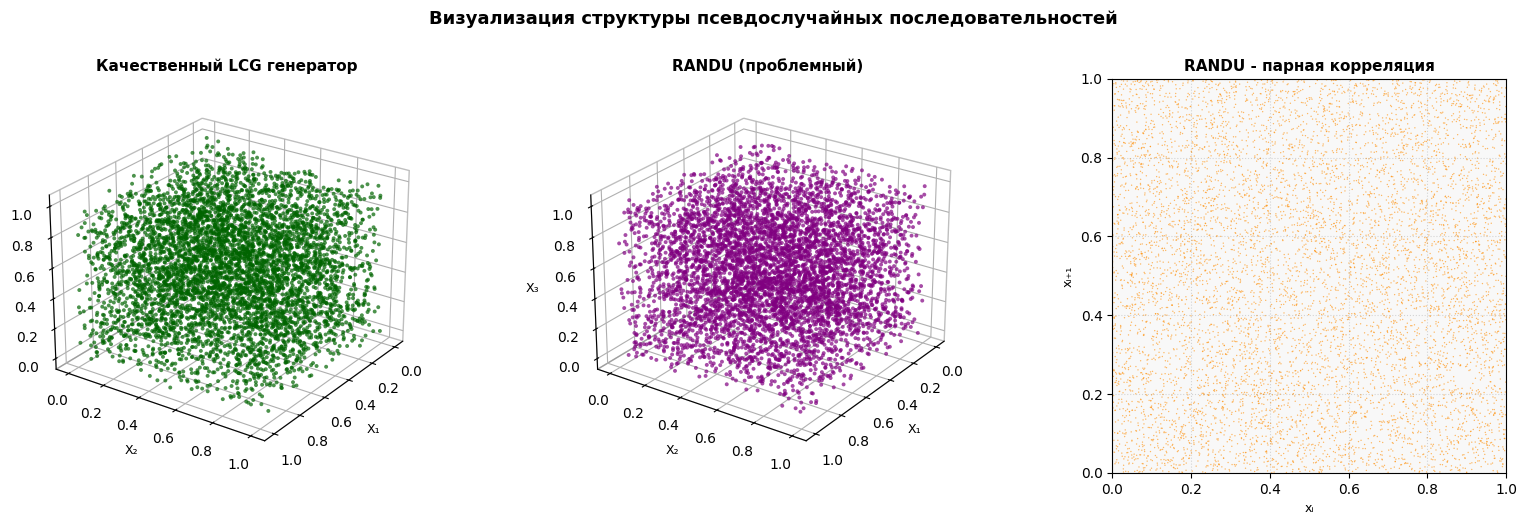

In [16]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

def rng_good(m=2**32, a=1103515245, c=12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m
rng_good.current = 1

def serial_test(samples, bins=10):
    n = len(samples) // 2 * 2
    pairs = np.array([samples[:n:2], samples[1:n:2]]).T
    observed, _, _ = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=bins)
    observed = observed.flatten()
    expected = np.full(bins * bins, n // 2 / (bins * bins))
    chi2_stat, p_value = stats.chisquare(observed, expected)
    return chi2_stat, p_value

def test_rng_quality(rng_func, name, n_samples=800000):
    samples = [rng_func() for _ in range(n_samples)]
    print(f"\n{name}")
    print("-" * 40)

    ks_stat, ks_p = stats.kstest(samples, stats.uniform.cdf)
    print(f"Колмогоров-Смирнов: p-value = {ks_p:.6f} - {'✓' if ks_p > 0.05 else '✗'}")

    hist, _ = np.histogram(samples, bins=20)
    expected = np.full(20, n_samples / 20)
    chi2_stat, chi2_p = stats.chisquare(hist, expected)
    print(f"Хи-квадрат: p-value = {chi2_p:.6f} - {'✓' if chi2_p > 0.05 else '✗'}")

    serial_stat, serial_p = serial_test(samples)
    print(f"Serial тест: p-value = {serial_p:.6f} - {'✓' if serial_p > 0.05 else '✗'}")

    return samples

print("СРАВНЕНИЕ ГЕНЕРАТОРОВ СЛУЧАЙНЫХ ЧИСЕЛ")



samples_standard = test_rng_quality(rng_good, "Стандартный LCG")
samples_randu = test_rng_quality(rng_bad, "RANDU (проблемный)")

step = 50


samples_standard_3d = samples_standard[::step]
n_std = len(samples_standard_3d) // 3 * 3
samples_standard_3d = samples_standard_3d[:n_std]

samples_randu_3d = samples_randu[::step]
n_randu = len(samples_randu_3d) // 3 * 3
samples_randu_3d = samples_randu_3d[:n_randu]


samples_randu_2d = samples_randu[::step]
n_randu_2d = len(samples_randu_2d) // 2 * 2
samples_randu_2d = samples_randu_2d[:n_randu_2d]


fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(
    samples_standard_3d[::3],
    samples_standard_3d[1::3],
    samples_standard_3d[2::3],
    s=8, alpha=0.7, c='darkgreen', marker='o', edgecolors='none'
)
ax1.set_title('Качественный LCG генератор', fontsize=11, fontweight='bold')
ax1.set_xlabel('X₁', fontsize=9)
ax1.set_ylabel('X₂', fontsize=9)
ax1.set_zlabel('X₃', fontsize=9)
ax1.view_init(elev=25, azim=35)
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
ax1.xaxis.pane.set_edgecolor('gray')
ax1.yaxis.pane.set_edgecolor('gray')
ax1.zaxis.pane.set_edgecolor('gray')

ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(
    samples_randu_3d[::3],
    samples_randu_3d[1::3],
    samples_randu_3d[2::3],
    s=8, alpha=0.7, c='purple', marker='o', edgecolors='none'
)
ax2.set_title('RANDU (проблемный)', fontsize=11, fontweight='bold')
ax2.set_xlabel('X₁', fontsize=9)
ax2.set_ylabel('X₂', fontsize=9)
ax2.set_zlabel('X₃', fontsize=9)
ax2.view_init(elev=25, azim=35)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False
ax2.xaxis.pane.set_edgecolor('gray')
ax2.yaxis.pane.set_edgecolor('gray')
ax2.zaxis.pane.set_edgecolor('gray')


ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(
    samples_randu_2d[::2],
    samples_randu_2d[1::2],
    s=4, alpha=0.6, c='darkorange', marker='.', edgecolors='none'
)
ax3.set_title('RANDU - парная корреляция', fontsize=11, fontweight='bold')
ax3.set_xlabel('xᵢ', fontsize=9)
ax3.set_ylabel('xᵢ₊₁', fontsize=9)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3, linestyle=':', color='gray')
ax3.set_facecolor('#f8f8f8')

plt.suptitle('Визуализация структуры псевдослучайных последовательностей',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

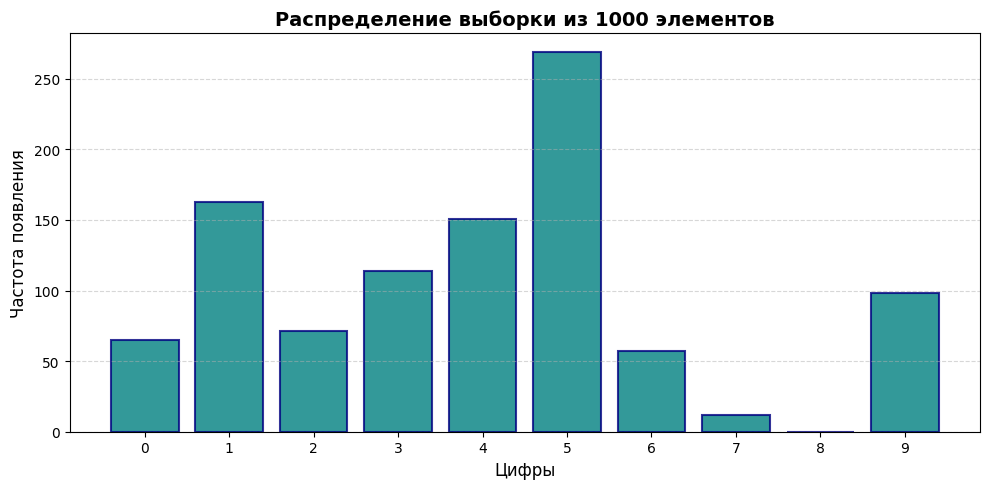

ТЕОРЕТИЧЕСКИЕ И ЭМПИРИЧЕСКИЕ ВЕРОЯТНОСТИ
Цифра    Теоретическая   Эмпирическая    Разница   
0        0.059731        0.065000        0.005269  
1        0.149328        0.163000        0.013672  
2        0.083126        0.071000        0.012126  
3        0.119462        0.114000        0.005462  
4        0.154306        0.151000        0.003306  
5        0.268790        0.269000        0.000210  
6        0.055251        0.057000        0.001749  
7        0.009955        0.012000        0.002045  
8        0.000498        0.000000        0.000498  
9        0.099552        0.098000        0.001552  
Сумма вероятностей: 1.000000
Сумма частот: 1.000000
Объем выборки: 1000


In [23]:
import numpy as np
import matplotlib.pyplot as plt

values_set = np.arange(10)
probabilities = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2], dtype=float)

probabilities = probabilities / probabilities.sum()

def generate_samples(count, elements, probs, random_seed=123):
    """Генерация дискретной выборки методом обратного преобразования"""
    random_gen = np.random.default_rng(random_seed)

    elements = np.asarray(elements)
    probs = np.asarray(probs, dtype=float)

    cumulative = np.cumsum(probs)
    result = np.empty(count, dtype=int)

    for idx in range(count):
        rand_val = random_gen.random()
        pos = 0
        while rand_val > cumulative[pos]:
            pos += 1
        result[idx] = elements[pos]

    return result


sample_size = 1000
generated = generate_samples(sample_size, values_set, probabilities, random_seed=42)


frequencies = np.bincount(generated, minlength=10)

plt.figure(figsize=(10, 5))
plt.bar(values_set, frequencies, color='teal', edgecolor='navy', linewidth=1.5, alpha=0.8)
plt.xticks(values_set)
plt.xlabel("Цифры", fontsize=12)
plt.ylabel("Частота появления", fontsize=12)
plt.title("Распределение выборки из 1000 элементов", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

empirical = frequencies / sample_size

print("ТЕОРЕТИЧЕСКИЕ И ЭМПИРИЧЕСКИЕ ВЕРОЯТНОСТИ")
print(f"{'Цифра':<8} {'Теоретическая':<15} {'Эмпирическая':<15} {'Разница':<10}")


for digit in values_set:
    theor = probabilities[digit]
    empir = empirical[digit]
    diff = abs(theor - empir)
    print(f"{digit:<8} {theor:<15.6f} {empir:<15.6f} {diff:<10.6f}")

print(f"Сумма вероятностей: {probabilities.sum():.6f}")
print(f"Сумма частот: {empirical.sum():.6f}")
print(f"Объем выборки: {sample_size}")

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

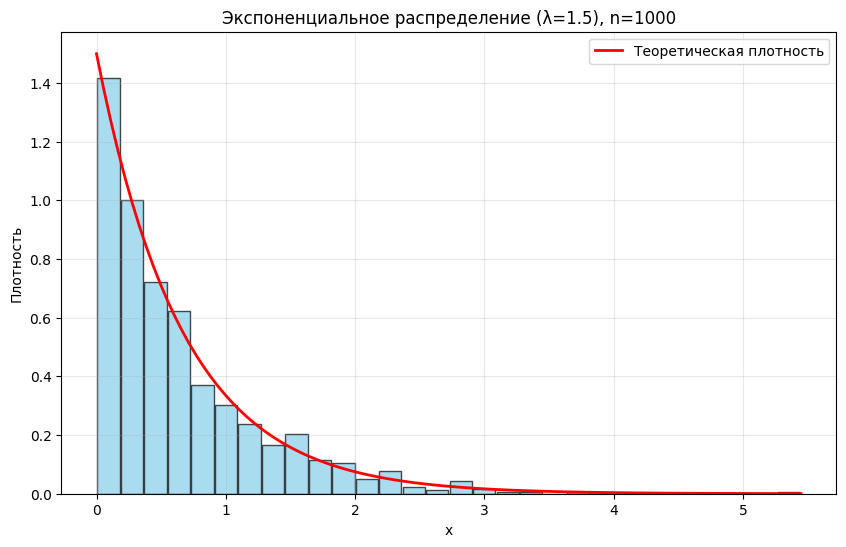

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def inverse_transform_exp(n, lambda_param=1.0, seed=42):
    np.random.seed(seed)
    u = np.random.random(n)
    samples = -np.log(1 - u) / lambda_param
    return samples

lambda_param = 1.5
n_samples = 1000

samples = inverse_transform_exp(n_samples, lambda_param)

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.7,
         color='skyblue', edgecolor='black', rwidth=0.95)
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(f'Экспоненциальное распределение (λ={lambda_param}), n={n_samples}')

x = np.linspace(0, np.max(samples), 100)
pdf_theor = lambda_param * np.exp(-lambda_param * x)
plt.plot(x, pdf_theor, 'r-', linewidth=2, label='Теоретическая плотность')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

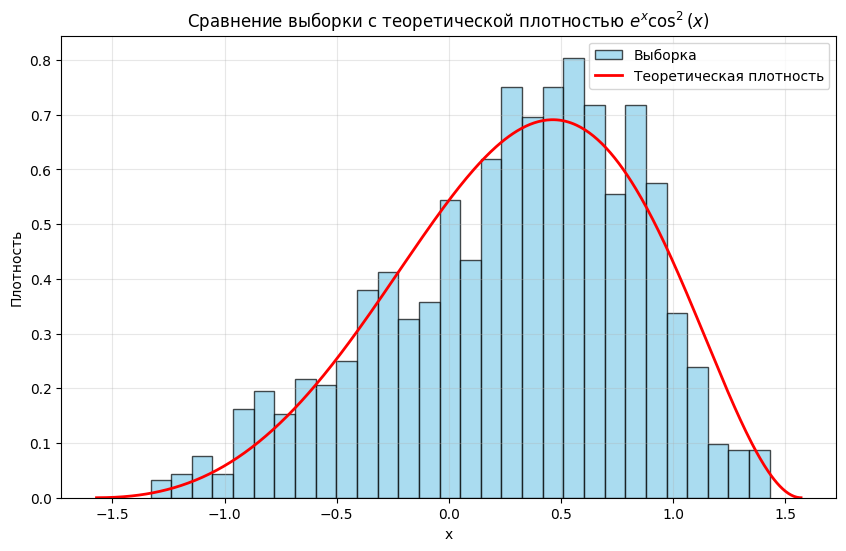

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def target_density(x):
    return np.exp(x) * np.cos(x)**2


a, b = -np.pi/2, np.pi/2


x_vals = np.linspace(a, b, 1000)
max_density = np.max(target_density(x_vals))
M = max_density * 1.1


def accept_reject(n_samples, a, b, M, seed=42):
    np.random.seed(seed)
    samples = []

    while len(samples) < n_samples:
        x = np.random.uniform(a, b)
        y = np.random.uniform(0, M)

        if y < target_density(x):
            samples.append(x)

    return np.array(samples)


n_samples = 1000
samples = accept_reject(n_samples, a, b, M)

x_integral = np.linspace(a, b, 10000)
dx = x_integral[1] - x_integral[0]
norm_const = np.sum(target_density(x_integral)) * dx

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.7,
         color='skyblue', edgecolor='black', label='Выборка')

x_plot = np.linspace(a, b, 500)
density_norm = target_density(x_plot) / norm_const
plt.plot(x_plot, density_norm, 'r-', linewidth=2, label='Теоретическая плотность')

plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(r'Сравнение выборки с теоретической плотностью $e^x \cos^2(x)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

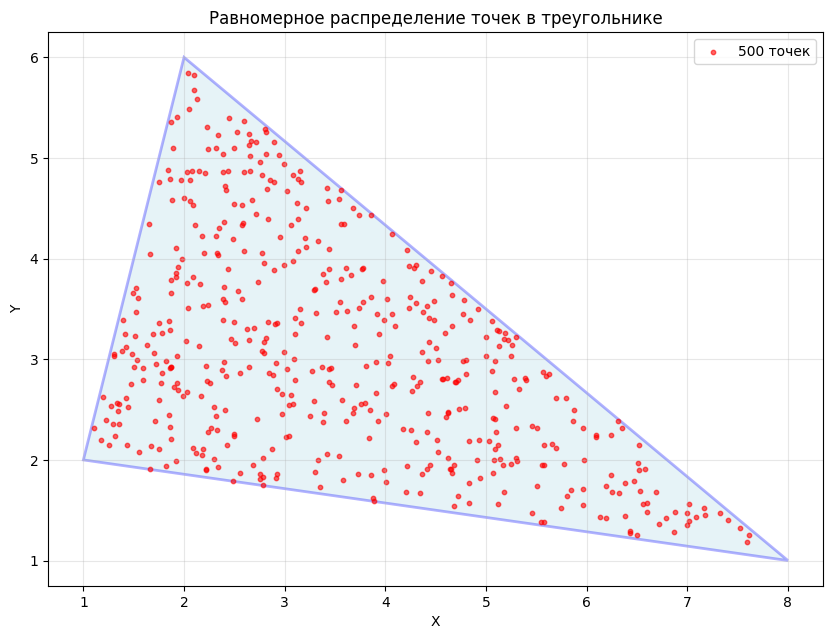

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


vertices = np.array([[1, 2], [2, 6], [8, 1]])


def random_points_in_triangle(n_points, vertices, seed=42):
    np.random.seed(seed)


    r1 = np.random.random(n_points)
    r2 = np.random.random(n_points)


    sqrt_r1 = np.sqrt(r1)
    u = 1 - sqrt_r1
    v = sqrt_r1 * (1 - r2)
    w = sqrt_r1 * r2

    points = np.outer(u, vertices[0]) + np.outer(v, vertices[1]) + np.outer(w, vertices[2])

    return points


n_points = 500
points = random_points_in_triangle(n_points, vertices)


fig, ax = plt.subplots(figsize=(10, 8))

polygon = Polygon(vertices, closed=True, facecolor='lightblue', edgecolor='blue', alpha=0.3, linewidth=2)
ax.add_patch(polygon)

ax.scatter(points[:, 0], points[:, 1], s=10, color='red', alpha=0.6, label=f'{n_points} точек')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Равномерное распределение точек в треугольнике')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

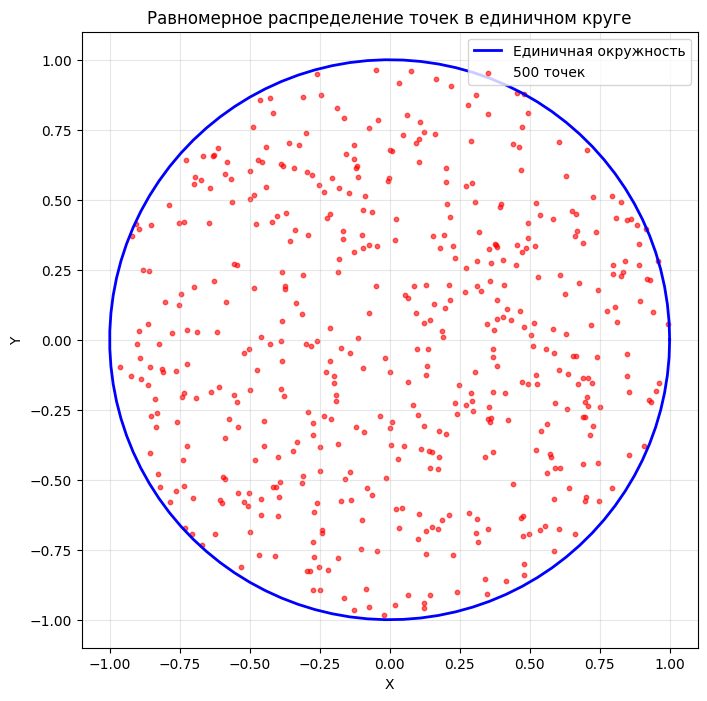

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def random_points_in_circle_polar(n_points, seed=42):
    """
    Генерация равномерно распределенных точек в круге
    с использованием полярных координат
    """
    np.random.seed(seed)

    theta = 2 * np.pi * np.random.random(n_points)
    r = np.sqrt(np.random.random(n_points))

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return x, y

n_points = 500
x, y = random_points_in_circle_polar(n_points)


fig, ax = plt.subplots(figsize=(8, 8))

t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), 'b-', linewidth=2, label='Единичная окружность')

ax.scatter(x, y, s=10, color='red', alpha=0.6, label=f'{n_points} точек')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Равномерное распределение точек в единичном круге')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

plt.show()



### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

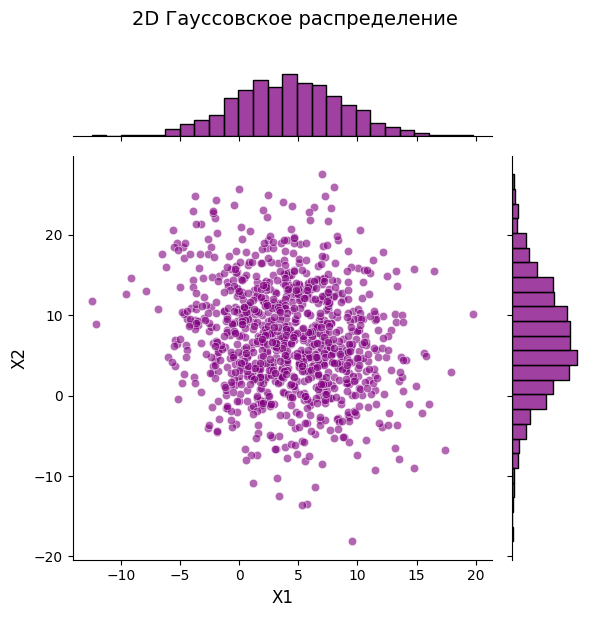

СРАВНЕНИЕ С ТЕОРЕТИЧЕСКИМИ ЗНАЧЕНИЯМИ

Среднее значение:
  Теоретическое: μ = [4, 7]
  Выборочное:    μ̂ = [4.0933, 7.0769]
  Ошибка:        [0.0933, 0.0769]

Ковариационная матрица:
  Теоретическая:
    [20, -4]
    [-4, 40]
  Выборочная:
    [21.0788, -5.7699]
    [-5.7699, 45.8375]


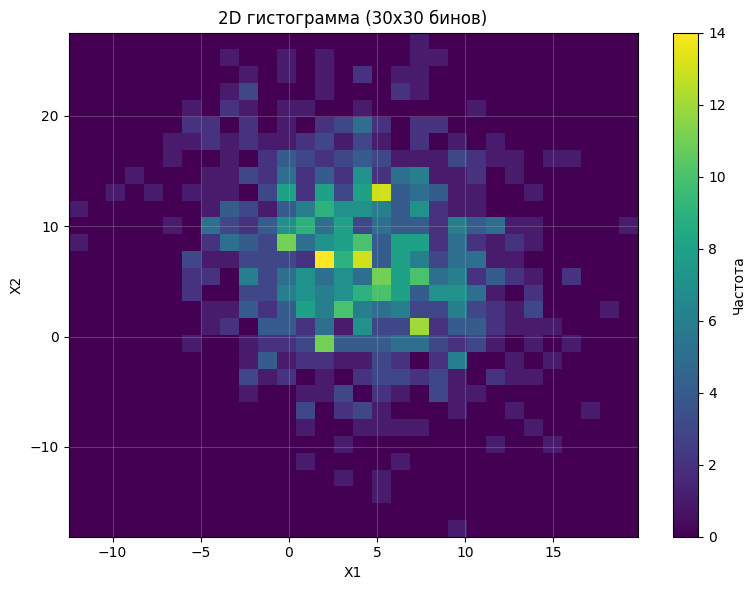

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])


L = np.linalg.cholesky(Sigma)

def box_muller_polar(n):
    """
    Полярная форма метода Box-Muller (без sin/cos)
    Возвращает n пар независимых стандартных нормальных величин
    """
    z = np.zeros((2, n))

    i = 0
    while i < n:

        u1 = 2 * np.random.random() - 1
        u2 = 2 * np.random.random() - 1
        s = u1**2 + u2**2


        if 0 < s < 1:

            factor = np.sqrt(-2 * np.log(s) / s)
            z[0, i] = u1 * factor
            z[1, i] = u2 * factor
            i += 1

    return z[0, :], z[1, :]


n = 1000
z1, z2 = box_muller_polar(n)
z = np.vstack([z1, z2])


x = mu[:, np.newaxis] + L @ z


joint_plot = sns.jointplot(x=x[0, :], y=x[1, :], color='purple', alpha=0.6)
joint_plot.set_axis_labels('X1', 'X2', fontsize=12)
plt.suptitle('2D Гауссовское распределение', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


print("="*60)
print("СРАВНЕНИЕ С ТЕОРЕТИЧЕСКИМИ ЗНАЧЕНИЯМИ")
print("="*60)


sample_mean = np.mean(x, axis=1)
print("\nСреднее значение:")
print(f"  Теоретическое: μ = [{mu[0]}, {mu[1]}]")
print(f"  Выборочное:    μ̂ = [{sample_mean[0]:.4f}, {sample_mean[1]:.4f}]")
print(f"  Ошибка:        [{sample_mean[0]-mu[0]:.4f}, {sample_mean[1]-mu[1]:.4f}]")


sample_cov = np.cov(x)
print("\nКовариационная матрица:")
print("  Теоретическая:")
print(f"    [{Sigma[0,0]}, {Sigma[0,1]}]")
print(f"    [{Sigma[1,0]}, {Sigma[1,1]}]")
print("  Выборочная:")
print(f"    [{sample_cov[0,0]:.4f}, {sample_cov[0,1]:.4f}]")
print(f"    [{sample_cov[1,0]:.4f}, {sample_cov[1,1]:.4f}]")


fig, ax = plt.subplots(figsize=(8, 6))
h = ax.hist2d(x[0, :], x[1, :], bins=30, cmap='viridis')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('2D гистограмма (30x30 бинов)')
plt.colorbar(h[3], ax=ax, label='Частота')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()